In [70]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score

In [71]:
%store -r dado_frame    

In [72]:
# ============================================================================
# Aqui a ideia e separar as features da target, para isso eu peguei todas 
# as colunas do data frame e retirei as colunas de timestamp e target_iALL_PS
# porque a coluna de timestamp e a coluna de target_iALL_PS não são features
#=============================================================================
features_coluna = [coluna for coluna in dado_frame.columns if coluna not in ['timestamp','target_iALL_PS']]   

In [73]:
#==============================================================================
# Aqui eu separo os dados features(X) e target(y) para o target eu considerei
# o valor "ANORMAL" como 1 e outros com 0 pois o meu modelo é de classificação 
# binária
#==============================================================================

X = dado_frame[features_coluna]
y = (dado_frame['target_iALL_PS'] == ('ANORMAL')).astype(int)

In [74]:
print(X)

       TAG_iALL_PS_49  TAG_iALL_PS_39  TAG_iALL_PS_17  TAG_iALL_PS_05  \
0          124.735196      120.531554      223.192894       97.284889   
1          212.607133       93.795994      707.464353       92.163633   
2          185.450615       88.206134      694.180396      172.193901   
3           66.392785       46.812500     1020.202310      241.856210   
4           85.033196       72.405479     1108.480969      100.275980   
...               ...             ...             ...             ...   
44059      158.311031       74.757406     1008.495565       42.972501   
44060      203.339101       71.312859     1256.499771      161.978442   
44061      136.808331       64.418113      985.811613      117.890485   
44062      237.760918      117.364068      968.841578       72.867374   
44063      199.902569       26.951498      573.821696      172.833101   

       TAG_iALL_PS_14  TAG_iALL_PS_50  TAG_iALL_PS_23  TAG_iALL_PS_11  \
0          813.860487      426.651658     2220.187

In [75]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
44059    0
44060    0
44061    0
44062    0
44063    0
Name: target_iALL_PS, Length: 44064, dtype: int64


In [76]:
print(X.shape)

(44064, 51)


In [77]:
print(y.shape)

(44064,)


In [78]:
soma_y = y.sum() 
media_y = y.mean() * 100
print(soma_y)
print(media_y)

2900
6.581336238198983


In [ ]:
#=============================================================================
# Aqui eu faço a divisão dos dados em treino e teste usando amostragem estratificada
#dividir os dados em treino e teste usando amotragem estratificada ela garante que a 
#a proporçção de classes seja mantida, tanto no conjunto de treino quanto no conjunto de testes.
# usa uma quantiidade de amostrar para ter o menor  erro.
#============================================================================ 

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for (treino_index, teste_index) in sss.split(X,y):
    X_treino, X_teste = X.iloc[treino_index], X.iloc[teste_index]
    y_treino, y_teste = y.iloc[treino_index], y.iloc[teste_index] 

 
y_treino_soma = y_treino.sum()
y_teste_soma = y_teste.sum() 

print(y_treino_soma) 
print(y_teste_soma)


2320
580


In [80]:
#=============================================================================
# para a primeira parte eu apliquei o modelo de arvore de decisão
# ela é um modelo de classificação que funciona como uma árvore de decisão
# onde cada nó representa uma decisão com base em uma feature, e cada ramo 
# representa o resultado dessa decisão
#=============================================================================

arvore_decisao = DecisionTreeClassifier(
    max_depth=5, #controla a profundidade da arvore
    class_weight='balanced', #como os dados são desbalanceados, 'balanced' compensa o desbalanceamento
    random_state=42 #garante a reproducibilidade do modelo
) 

arvore_decisao.fit(X_treino, y_treino)

y_predicao_arvore = arvore_decisao.predict(X_teste)
y_probilodade_arvore = arvore_decisao.predict_proba(X_teste)[:,1]

print("Arvore de decisaõ:")
print(classification_report(y_teste, y_predicao_arvore,target_names=['NORMAL', 'ANORMAL']))

Arvore de decisaõ:
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      0.99      8233
     ANORMAL       0.84      0.97      0.90       580

    accuracy                           0.99      8813
   macro avg       0.92      0.98      0.95      8813
weighted avg       0.99      0.99      0.99      8813



Arvore de decisaõ:


              precision  recall   f1-score   support
NORMAL          1.00      0.99      0.99      8233
ANORMAL         0.84      0.97      0.90      580

accuracy                            0.99      8813
macro avg       0.92      0.98      0.95      8813
weighted avg    0.99      0.99      0.99      8813

O desempenho do modelo tem

* precisão $\rightarrow$ isso que dizer que algo como "de todas as vezes que o modelo previu a classe positiva, quantas vezes ele acertou?" considerando isso em 100 vezes que o modelo previu a classe normal ele acertou 100% das vezes. para a classe anormal a precisão é de 0.84, ou seja, de todas as vezes que o modelo previu a classe anormal ele acertou 84% das vezes.

* recall $\rightarrow$ essa metrica respode a pergunta "de todas as vezes que a classe positiva realmente ocorreu, quantas vezes o modelo previu a classe positiva?" considerando isso, o modelo previu a classe normal 99% das vezes que ela realmente ocorreu, e para a classe anormal o modelo previu 97% das vezes que ela realmente ocorreu.

* f1-score $\rightarrow$ é a média harmônica entre precisão e recall, ela é uma métrica que busca um equilíbrio entre precisão e recall. para a classe normal o f1-score é de 0.99, e para a classe anormal o f1-score é de 0.90.

* support $\rightarrow$ é o número de ocorrências de cada classe no conjunto de teste. para a classe normal temos 8233 ocorrências, e para a classe anormal temos 580 ocorrências. 

In [81]:
# Floresta aleatória
floresta_aleatoria = RandomForestClassifier(
    n_estimators=100, # 100 árvores no ensemble
    max_depth=12, # profundidade máxima de cada árvore
    min_samples_leaf=10, # evita overfitting em folhas pequenas
    class_weight='balanced', # compensa o desbalanceamento (97.5% NORMAL / 2.5% ANORMAL)
    random_state=42, # garante reprodutibilidade
    n_jobs=-1 # usa todos os núcleos do processador
)

floresta_aleatoria.fit(X_treino, y_treino)

y_predicao_floresta = floresta_aleatoria.predict(X_teste)
y_probilodade_floresta = floresta_aleatoria.predict_proba(X_teste)[:,1]

print("Floresta aleatória:")
print(classification_report(y_teste, y_predicao_floresta, target_names=['NORMAL', 'ANORMAL']))
 


Floresta aleatória:
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      1.00      8233
     ANORMAL       0.91      0.98      0.94       580

    accuracy                           0.99      8813
   macro avg       0.95      0.98      0.97      8813
weighted avg       0.99      0.99      0.99      8813



Floresta aleatória:
              precision    recall  f1-score   support

      NORMAL       1.00      0.99      1.00      8233
     ANORMAL       0.91      0.98      0.94       580

    accuracy                           0.99      8813
   macro avg       0.95      0.98      0.97      8813
weighted avg       0.99      0.99      0.99      8813


O desempenho do modelo tem

* precisão $\rightarrow$ isso que dizer que algo como "de todas as vezes que o modelo previu a classe positiva, quantas vezes ele acertou?" considerando isso em 100 vezes que o modelo previu a classe normal ele acertou 100% das vezes. para a classe anormal a precisão é de 0.91, ou seja, de todas as vezes que o modelo previu a classe anormal ele acertou 91% das vezes.

* recall $\rightarrow$ essa metrica respode a pergunta "de todas as vezes que a classe positiva realmente ocorreu, quantas vezes o modelo previu a classe positiva?" considerando isso, o modelo previu a classe normal 99% das vezes que ela realmente ocorreu, e para a classe anormal o modelo previu 98% das vezes que ela realmente ocorreu.

* f1-score $\rightarrow$ é a média harmônica entre precisão e recall, ela é uma métrica que busca um equilíbrio entre precisão e recall. para a classe normal o f1-score é de 1.00, e para a classe anormal o f1-score é de 0.94.

* support $\rightarrow$ é o número de ocorrências de cada classe no conjunto de teste. para a classe normal temos 8233 ocorrências, e para a classe anormal temos 580 ocorrências.

        

In [82]:
#==========================================================================
# Calculo do AUC-ROC para ambos os modelos, o AUC-ROC avalia o desempenho 
# do modelo, se tiver proximo de 1 o modelo tem um bom desempenho, caso 
# contrário modelo ruim
#==========================================================================

roc_arvore = roc_auc_score(y_teste, y_probilodade_arvore)
roc_floresta = roc_auc_score(y_teste, y_probilodade_floresta)

In [83]:

print(f"{roc_arvore:.4f}")
print(f"{roc_floresta:.4f}")

0.9811
0.9966


In [84]:
#=========================================================================
# Obter as features mais importante do random forest, para conseguir criar
# uma analise descritiva usando grafico de dispersao
#=========================================================================
 
features_importantes = pd.Series(floresta_aleatoria.feature_importances_, index=features_coluna)
features_importantes_10 = features_importantes.sort_values(ascending=False)

print(features_importantes_10[:5])
print(features_importantes[0:5])

TAG_iALL_PS_50    0.247327
TAG_iALL_PS_13    0.199717
TAG_iALL_PS_00    0.123509
TAG_iALL_PS_12    0.119083
TAG_iALL_PS_48    0.056055
dtype: float64
TAG_iALL_PS_49    0.001827
TAG_iALL_PS_39    0.002181
TAG_iALL_PS_17    0.000424
TAG_iALL_PS_05    0.011169
TAG_iALL_PS_14    0.000418
dtype: float64


In [85]:
features_importantes_10 = features_importantes_10
%store features_importantes_10

Stored 'features_importantes_10' (Series)


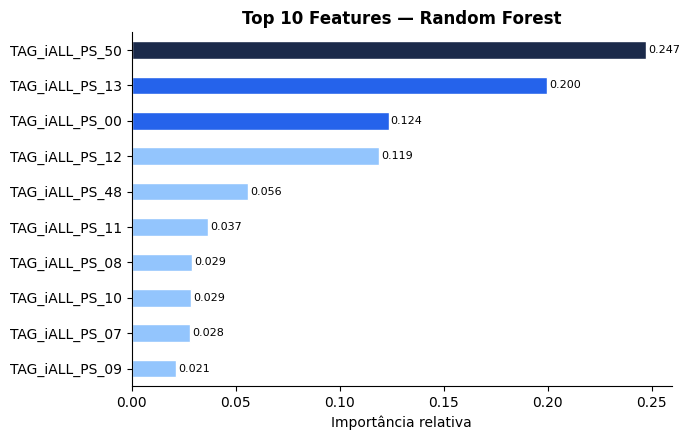

In [86]:
fi_top10 = features_importantes_10.head(10)

fig, ax = plt.subplots(figsize=(7, 4.5))
cores_fi = ['#1B2A4A' if i == 0 else '#2563EB' if i < 3 else '#93C5FD'
            for i in range(len(fi_top10))]

fi_top10.sort_values().plot(kind='barh', ax=ax, color=cores_fi[::-1], edgecolor='white')

for i, (v, label) in enumerate(zip(fi_top10.sort_values().values,
                                    fi_top10.sort_values().index)):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

ax.set_title('Top 10 Features — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importância relativa')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

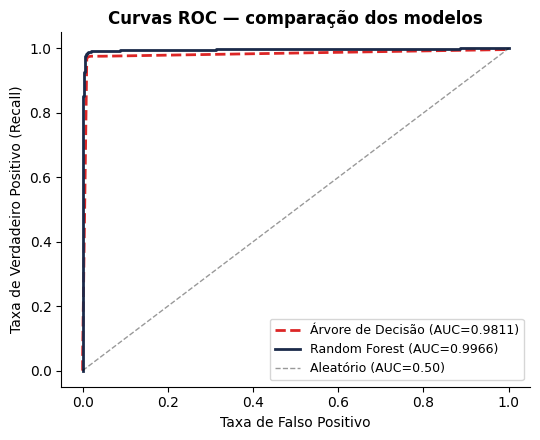

In [87]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(5.5, 4.5))

for nome, prob, cor, ls in [
    ('Árvore de Decisão', y_probilodade_arvore,   '#DC2626', '--'),
    ('Random Forest',     y_probilodade_floresta, '#1B2A4A', '-'),
]:
    fpr, tpr, _ = roc_curve(y_teste, prob)
    auc = roc_auc_score(y_teste, prob)
    ax.plot(fpr, tpr, color=cor, lw=2, linestyle=ls, label=f'{nome} (AUC={auc:.4f})')

ax.plot([0,1], [0,1], 'k--', lw=1, alpha=0.4, label='Aleatório (AUC=0.50)')
ax.set_xlabel('Taxa de Falso Positivo')
ax.set_ylabel('Taxa de Verdadeiro Positivo (Recall)')
ax.set_title('Curvas ROC — comparação dos modelos', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafico_roc.png', dpi=130, bbox_inches='tight')
plt.show()

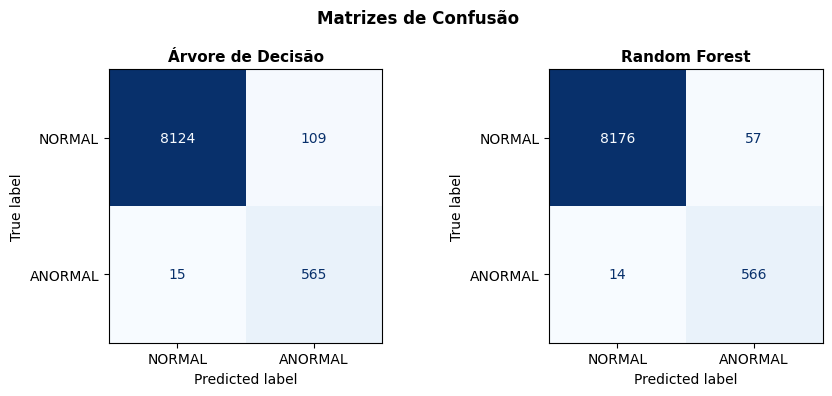

In [88]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, yp, titulo in [
    (axes[0], y_predicao_arvore,   'Árvore de Decisão'),
    (axes[1], y_predicao_floresta, 'Random Forest'),
]:
    cm = confusion_matrix(y_teste, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'ANORMAL'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=11, fontweight='bold')

fig.suptitle('Matrizes de Confusão', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_confusion.png', dpi=130, bbox_inches='tight')
plt.show()